## **Install Dependencies**

In [1]:
!pip install torchmetrics torchvision

In [2]:
!pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.9 MB/s eta 0:00:00


In [3]:
!pip install torch-fidelity

In [4]:
# Get classifier model for inception score computation
!git clone --branch feat/classifiers https://github.com/SaraElwatany/Generative-Models.git

Cloning into 'Generative-Models'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 70 (delta 0), reused 0 (delta 0), pack-reused 67 (from 1)
Receiving objects: 100% (70/70), 245.68 MiB | 28.60 MiB/s, done.
Resolving deltas: 100% (8/8), done.


## **Import Dependencies**

In [43]:
import os
import torch
import random
import torchvision
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision.utils import save_image
from torch.utils.data import ConcatDataset
from torchvision import datasets, transforms, models
from torchvision.transforms.functional import resize
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance

In [6]:
!mkdir /kaggle/working/checkpoints /kaggle/working/generated_samples

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
print('Current Device is:', device)

Current Device is: cuda


## **Helper Functions**

In [9]:
def load_mnist_data(batch_size=32):

    """
    Function that is used to load the Mnist Dataset.
    The Mnist dataset consists of grey scale images and the images in the dataset are in the shape of (1, 28, 28).
    The function applies transformations to the images and then divides the images into batches.

    Args:
        batch_size(int, optional): The size of the batch.

    Returns:
        class_names (list): The classes in the dataset.
        trainloader (DataLoader): The batched training data.
        testloader (DataLoader): The batched test data for evaluation purposes.
    """
    

    # Image transformations; Original Img Shape: (1, 28, 28)
    transform = transforms.Compose([transforms.Resize((32, 32)),
                                    transforms.ToTensor(),
                                ])

    # Load Datasets
    train_dataset = datasets.MNIST(
                                    root="./data",
                                    train=True,
                                    download=True,
                                    transform=transform
                                )
    
    test_dataset = datasets.MNIST(
                                    root="./data",
                                    train=False,
                                    download=True,
                                    transform=transform
                                )



    # Get Dataloaders
    trainloader = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=batch_size, 
                                              shuffle=True,
                                              num_workers=2,
                                              pin_memory=True)


    
    
    testloader = torch.utils.data.DataLoader(test_dataset,
                                             batch_size=batch_size, 
                                             shuffle=False,
                                             num_workers=2,
                                             pin_memory=True)

    # Get classes names
    class_names = test_dataset.classes

    
    return  class_names, trainloader, testloader

In [10]:
def load_flowers_data(batch_size=16, img_size=32, combine_dataset=False):

    """
    Function that is used to load the Oxford Flowers Dataset.
    The Flowers dataset consists of RGB images and the images in the dataset are in the shape of (3, 224, 224).
    The function applies transformations to the images and then divides the images into batches.

    Args:
        batch_size(int, optional): The size of the batch.
        img_size (int, optional): The desired height and width dimensions of the transformed images.
        combine_dataset (bool, optional): A flag that specifies whether we want the training dataset to include also the testing data or just combine the training and validation parts.

    Returns:
        class_names (list): The classes in the dataset.
        trainloader (DataLoader): The batched training data.
        testloader (DataLoader): The batched test data for evaluation purposes.
    """
    

    # Image transformations; Original Image Shape: (3, 224, 224)
    transform = transforms.Compose([transforms.Resize((img_size, img_size)),          
                                    transforms.ToTensor(), 
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    # Load Datasets
    train_dataset = datasets.Flowers102(
                                            root="./data",
                                            split="train",
                                            download=True,
                                            transform=transform
                                        )

    val_dataset = datasets.Flowers102(
                                    root="./data",
                                    split="val",
                                    download=True,
                                    transform=transform
                                  )

    
    test_dataset = datasets.Flowers102(
                                        root="./data",
                                        split="test",
                                        download=True,
                                        transform=transform
                                      )

    # If combine flag is set, then we set the train, validation and test parts of the flower dataset as our new training dataset
    if combine_dataset:
        train_dataset = ConcatDataset([train_dataset, val_dataset])
    else:
        train_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])


    # Get Dataloaders
    trainloader = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=batch_size, 
                                              shuffle=True,
                                              num_workers=2,
                                              pin_memory=True)


    
    
    testloader = torch.utils.data.DataLoader(test_dataset,
                                             batch_size=batch_size, 
                                             shuffle=False,
                                             num_workers=2,
                                             pin_memory=True)

    # Get classes names
    class_names = test_dataset.classes

    
    return  class_names, trainloader, testloader

In [11]:
def load_cifar_data(batch_size=16):
    
    """
    Function that is used to load the CIFAR10 Dataset.
    The CIFAR dataset consists of RGB images and the images in the dataset are in the shape of (3, 32, 32).
    The function applies transformations to the images and then divides the images into batches.

    Args:
        batch_size(int, optional): The size of the batch.

    Returns:
        class_names (list): The classes in the dataset.
        trainloader (DataLoader): The batched training data.
        testloader (DataLoader): The batched test data for evaluation purposes.
    """
    

    # Image transformations; Original Image Shape of CIFAR10: (3, 32, 32)
    transform = transforms.Compose([transforms.ToTensor(), 
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    # Load Datasets
    trainset = datasets.CIFAR10(root='./data', 
                                train=True, 
                                download=True,
                                transform=transform)

    testset = datasets.CIFAR10(root='./data', 
                               train=False, 
                               download=True,
                               transform=transform)
    
    # Get Dataloaders
    trainloader = torch.utils.data.DataLoader(trainset,
                                              batch_size=batch_size, 
                                              shuffle=True,
                                              num_workers=2,
                                              pin_memory=True)


    
    
    testloader = torch.utils.data.DataLoader(testset,
                                             batch_size=batch_size, 
                                             shuffle=False,
                                             num_workers=2,
                                             pin_memory=True)

    # Get classes names
    class_names = trainset.classes

    return  class_names, trainloader, testloader

In [12]:
def show_samples(data_loader, class_names=None, n=6, binary=False):

    """
    Function that is used to display samples from a given dataset.

    Args:
        data_loader (DataLoader): The dataloader that we will show samples from.
        class_names (List, optional): The class names for each data sample.
        n (int, optional): The number of samples to display.
        binary (bool, optional): A flag that specifies whether we are displaying a black and white image or a colored one.

    Returns:
        None
    """
    
    images, labels = next(iter(data_loader))
    
    # Pick n random indices
    indices = random.sample(range(len(images)), n)
    
    # Select images and labels
    images = images[indices]
    labels = labels[indices]
    
    # Make a grid
    grid = torchvision.utils.make_grid(images, nrow=n)
    grid = grid.permute(1, 2, 0).cpu()  # C,H,W → H,W,C

    if not binary:
        grid = grid / 2 + 0.5  # Undo normalization [-1,1] → [0,1]
    
    plt.figure(figsize=(n*2, 2))
    plt.imshow(grid)
    plt.axis("off")
    
    if class_names is not None:
        label_names = [class_names[l] for l in labels]
        plt.title(" | ".join(label_names))
    
    plt.show()

In [13]:
def get_classifier_model(num_classes):
    
    """
    Initializes a ResNet-18 model pretrained on ImageNet and adapts it
    for a custom classification task.

    The final fully connected (fc) layer is replaced to match the desired
    number of output classes.

    Args:
        num_classes (int):
            Number of target classes for the classification task.

    Returns:
        torch.nn.Module:
            Modified ResNet-18 model with pretrained weights and a new
            fully connected layer of size [in_features, num_classes].

    Notes:
        - The feature extractor layers remain unchanged, while only the final
          classification layer is modified.
    """
    
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

In [14]:
def get_time_embedding(time_steps, temb_dim):

     """
    Converts timesteps into sinusoidal positional embeddings.

    Args:
        time_steps (torch.Tensor): 1D tensor of timesteps, shape (B,).
        temb_dim (int): Embedding dimension (must be even).

    Returns:
        torch.Tensor: Sinusoidal embeddings of shape (B, temb_dim).
    """

    assert temb_dim % 2 == 0, "time embedding dimension must be divisible by 2"
    
    # factor = 10000^(2i/d_model)
    factor = 10000 ** ( (torch.arange(
        start=0, end=temb_dim // 2, dtype=torch.float32, device=time_steps.device) / (temb_dim // 2) )
    )
    
    # pos / factor
    # timesteps B -> B, 1 -> B, temb_dim
    t_emb = time_steps[:, None].repeat(1, temb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    
    return t_emb

In [15]:
def train_model(model, optimizer, lr_scheduler, train_dataloader, device=device, epochs=100, beta_start=0.0001, beta_end=0.02, num_timesteps=1000, patience=5, min_delta=0.0001, early_stopping=False, checkpoint_dir="./checkpoints", checkpoint_path="./checkpoints/checkpoint.pt"):

    """
    Trains a diffusion model using a linear noise scheduler.

    Args:
        model (nn.Module): The denoising model to train.
        optimizer (torch.optim.Optimizer): Optimizer for updating model weights.
        lr_scheduler: Learning rate scheduler.
        train_dataloader (DataLoader): Dataloader supplying training image batches.
        device (torch.device): Device to run training on. Defaults to global `device`.
        epochs (int): Maximum number of training epochs. Defaults to 100.
        beta_start (float): Starting beta value for the noise scheduler. Defaults to 0.0001.
        beta_end (float): Ending beta value for the noise scheduler. Defaults to 0.02.
        num_timesteps (int): Total diffusion timesteps. Defaults to 1000.
        patience (int): Epochs without improvement before early stopping triggers. Defaults to 5.
        min_delta (float): Minimum loss improvement to be considered progress. Defaults to 0.0001.
        early_stopping (bool): Whether to enable early stopping. Defaults to False.
        checkpoint_dir (str): Directory to save checkpoints. Defaults to './checkpoints'.
        checkpoint_path (str): Full path for saving/loading the checkpoint file. Defaults to './checkpoints/checkpoint.pt'.

    Returns:
        None. Prints training progress and saves the best checkpoint to `checkpoint_path`.
    """

    
    # Early stopping parameters
    best_loss = float('inf')
    counter = 0

    if not early_stopping:
        patience = epochs

    
    # Create the noise scheduler
    scheduler = LinearNoiseScheduler(num_timesteps=num_timesteps,
                                     beta_start=beta_start,
                                     beta_end=beta_end)
    
    


    # Set the model to training mode
    model.train()
    
    # Create output directories
    if not os.path.exists(checkpoint_dir):
        os.mkdir(checkpoint_dir)
    
    # Load checkpoint if found
    if os.path.exists(checkpoint_path):

        print(f'Loading checkpoint: {checkpoint_path}')

        checkpoint = torch.load(checkpoint_path, map_location=device)

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        start_epoch = checkpoint['epoch']

        print(f"Resuming training from epoch {start_epoch}")


    
    # Run training
    for epoch in range(epochs):

        total_loss = 0
        losses = []
        
        for images, _ in train_dataloader:
            
            #
            images= images.float().to(device)

            #
            optimizer.zero_grad()
            
            # Sample random noise
            noise = torch.randn_like(images).to(device)
            
            # Sample timestep
            t = torch.randint(0, num_timesteps, (images.shape[0],)).to(device)
            
            # Add noise to images according to timestep
            noisy_im = scheduler.add_noise(images, noise, t)
            noise_pred = model(noisy_im, t)

            loss = criterion(noise_pred, noise)
            total_loss += loss.item()
            
            losses.append(loss.item())
            
            loss.backward()
            
            optimizer.step()
            
            
        avg_loss = total_loss / len(train_dataloader.dataset)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
        

        # Step scheduler
        lr_scheduler.step(avg_loss)

        
        # Early Stopping Check
        if best_loss - avg_loss > min_delta:
            
            best_loss = avg_loss
            counter = 0
            
            # Save best model
            torch.save({
                            'epoch': epoch+1,
                            'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict(),
                            'loss': avg_loss
                        }, checkpoint_path)
            
            print(f"Checkpoint saved (best model): {checkpoint_path}")
            
        else:
            counter += 1
            print(f"No improvement for {counter} epoch(s)")
    
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
        

    print("Training Finished ...")

In [16]:
def compute_is_with_classifier(model, images, device=device, splits=10):

    """
    Computes the Inception Score (IS) for a set of generated images using a given classifier.

    The Inception Score evaluates both the quality and diversity of generated images by
    measuring the KL divergence between the conditional label distribution p(y|x) and the
    marginal distribution p(y).

    Args:
        model (torch.nn.Module):
            A pretrained classifier (e.g., Inception model or custom classifier) used to
            compute class probabilities p(y|x).

        images (Iterable[Tensor]):
            Iterable of image batches with shape [B, C, H, W]. Images should be properly
            preprocessed for the classifier.

        device (torch.device, optional):
            Device to run the computation on (CPU or GPU).

        splits (int, optional):
            Number of splits used to compute IS. Splitting improves stability by computing
            the score over subsets of data and reporting mean and standard deviation.

    Returns:
        Tuple[torch.Tensor, torch.Tensor]:
            - Mean Inception Score across splits.
            - Standard deviation of the Inception Score across splits.

    Notes:
        - Higher Inception Score indicates better performance (high confidence and diversity).
        - The classifier should be trained on a dataset similar to the generated images.
        - A small epsilon (1e-10) is added to probabilities to avoid numerical instability
          in log computations.
    """

    
    model.eval()
    preds = []

    with torch.no_grad():
        
        for batch in images:
            
            batch = batch.to(device)

            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)  # p(y|x)

            preds.append(probs.cpu())

    preds = torch.cat(preds, dim=0)  # [N, num_classes]

    # Split for stability
    N = preds.size(0)
    split_size = N // splits

    scores = []

    for i in range(splits):
        
        part = preds[i * split_size:(i + 1) * split_size]

        py = torch.mean(part, dim=0)  # p(y)

        kl = part * (torch.log(part + 1e-10) - torch.log(py + 1e-10))
        kl = torch.sum(kl, dim=1)

        scores.append(torch.exp(torch.mean(kl)))

    return torch.mean(torch.tensor(scores)), torch.std(torch.tensor(scores))

In [35]:
def eval_model(model, classifier_model, data_loader, batch_size=16, num_samples=100, im_channels=3, im_size=32, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device=device, checkpoint_path="./checkpoints/checkpoint.pt"):

    """
    Evaluates a trained diffusion model by generating images and computing FID and Inception Score.

    Args:
        model (nn.Module): The trained denoising model used for image generation.
        classifier_model (nn.Module): Pretrained classifier used to compute the Inception Score.
        data_loader (DataLoader): Dataloader supplying real images for FID computation.
        batch_size (int): Batch size for IS inference. Defaults to 16.
        num_samples (int): Number of images to generate and evaluate. Defaults to 100.
        im_channels (int): Number of image channels (1 for grayscale, 3 for RGB). Defaults to 3.
        im_size (int): Spatial resolution of generated images. Defaults to 32.
        num_timesteps (int): Total diffusion timesteps for reverse sampling. Defaults to 1000.
        beta_start (float): Starting beta for the noise scheduler. Defaults to 0.0001.
        beta_end (float): Ending beta for the noise scheduler. Defaults to 0.02.
        device (torch.device): Device to run evaluation on. Defaults to global `device`.
        checkpoint_path (str): Path to the model checkpoint to load. Defaults to './checkpoints/checkpoint.pt'.

    Returns:
        tuple:
            - fid_score (float): Fréchet Inception Distance between real and generated images.
            - is_score (float): Mean Inception Score of the generated images.
            - is_std (float): Standard deviation of the Inception Score.
    """


    
    # Load checkpoint if provided 
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])

  
    #
    model.eval()
    generated_images = []

    # Noise scheduler
    scheduler = LinearNoiseScheduler(num_timesteps=num_timesteps, beta_start=beta_start, beta_end=beta_end)

    #
    xt = torch.randn((num_samples, im_channels, im_size, im_size)).to(device)
                                     
                                     
    with torch.no_grad():

        for i in reversed(range(num_timesteps)):
            
            noise_pred = model(xt, torch.as_tensor(i).unsqueeze(0).to(device))
            xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

        # Only append final x0/final xt
        if im_channels == 1:
            imgs = torch.clamp(xt, 0., 1.).detach().cpu()

        else:
            imgs = torch.clamp(xt, -1., 1.).detach().cpu()
            imgs = (imgs + 1) / 2  # [0,1] range
            
        generated_images.append(imgs)
            

    generated_images = torch.cat(generated_images, dim=0)[:num_samples]
    print("Generated images shape:", generated_images.shape)

    # Collect real images
    real_images = []
    for i, (imgs, _) in enumerate(data_loader):
        
        real_images.append(imgs)
        if len(real_images)*batch_size >= num_samples:
            break
            

    real_images = torch.cat(real_images, dim=0)[:num_samples]
    print("Real images shape:", real_images.shape)

    
    if real_images.shape[1] == 1:
        real_images = real_images.repeat(1, 3, 1, 1)
        print("Real images reshaped to:", generated_images.shape)

    if generated_images.shape[1] == 1:
        generated_images = generated_images.repeat(1, 3, 1, 1)
        print("Generated images reshaped to:", generated_images.shape)

    
    # Convert back to 0-255 range
    real_images_uint8 = (real_images * 255).to(torch.uint8).to(device)
    generated_images_uint8 = (generated_images * 255).to(torch.uint8).to(device)


    
    #  -------------- Compute Fréchet Inception Distance (FID)  --------------
    
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)
    fid_metric.update(real_images_uint8.to(device), real=True)
    fid_metric.update(generated_images_uint8.to(device), real=False)
    fid_score = fid_metric.compute()
    print("FID score:", fid_score.item())



    #  -------------- Compute Inception Score (IS)  --------------
    
    # Apply SAME normalization used in training of classifier
    generated_images = generated_images_uint8.float() / 255.0
    generated_images = resize(generated_images, [224, 224])
    generated_images = (generated_images - torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)) / torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
                       
    # Create batches
    generated_loader = torch.utils.data.DataLoader(generated_images, batch_size=batch_size, shuffle=False)
    
    # Compute IS
    is_score, is_std = compute_is_with_classifier(classifier_model, generated_loader, device)
    print("Inception Score:", is_score.item(), "+/-", is_std.item())

    return fid_score.item(), is_score.item(), is_std.item()

In [18]:
def generate_samples(model_config, beta_start=0.0001, beta_end=0.02, num_timesteps=1000, num_samples=20, checkpoint_path='./checkpoints/checkpoint.pt'):

    """
    Generates and saves images from a trained diffusion model using reverse sampling.

    Args:
        model_config (dict): UNet configuration containing at minimum 'im_channels' and 'im_size'.
        beta_start (float): Starting beta for the noise scheduler. Defaults to 0.0001.
        beta_end (float): Ending beta for the noise scheduler. Defaults to 0.02.
        num_timesteps (int): Total diffusion timesteps for reverse sampling. Defaults to 1000.
        num_samples (int): Number of images to generate and save. Defaults to 20.
        checkpoint_path (str): Path to the model checkpoint to load. Defaults to './checkpoints/checkpoint.pt'.

    Returns:
        None. Saves generated images as PNGs to './generated_samples/sample_{idx}.png'.
    """


    model = Unet(model_config).to(device)
    

    # Load model with checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    #
    model.eval()
    
    # Create the noise scheduler
    scheduler = LinearNoiseScheduler(num_timesteps=num_timesteps, beta_start=beta_start, beta_end=beta_end)
                                     
                                     
    with torch.no_grad():
        
        xt = torch.randn((num_samples, model_config['im_channels'], model_config['im_size'], model_config['im_size'])).to(device)
        
        for i in reversed(range(num_timesteps)):
            
            # Get prediction of noise
            noise_pred = model(xt, torch.as_tensor(i).unsqueeze(0).to(device))
            
            # Use scheduler to get x0 and xt-1
            xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

            # 
            if model_config['im_channels'] == 1:
                imgs = torch.clamp(xt, 0., 1.).detach().cpu()
                
            else:
                imgs = torch.clamp(xt, -1., 1.).detach().cpu()                # Ensure [-1,1] range
                imgs = (imgs + 1) / 2                                         # Ensure [0,1] range
            

        
        for idx, img in enumerate(imgs):
            
            img = torchvision.transforms.ToPILImage()(img)
            img.save(os.path.join('./generated_samples', f'sample_{idx}.png'))
            img.close()

            img_path = os.path.join('./generated_samples', f'sample_{idx}.png')
            print(f"Sample {img_path} was generated successfully")

## **Model Architecture**

In [19]:
class LinearNoiseScheduler:
    

    def __init__(self, num_timesteps, beta_start, beta_end):
        
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end
        
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1. - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1 - self.alpha_cum_prod)


    
    def add_noise(self, original, noise, t):
    
            original_shape = original.shape
            batch_size = original_shape[0]
            
            sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
            sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
            
            # Reshape till (B,) becomes (B,1,1,1) if image is (B,C,H,W)
            for _ in range(len(original_shape) - 1):
                sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
                
            for _ in range(len(original_shape) - 1):
                sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)
            
            # Apply and Return Forward process equation
            return (sqrt_alpha_cum_prod.to(original.device) * original + sqrt_one_minus_alpha_cum_prod.to(original.device) * noise)



    def sample_prev_timestep(self, xt, noise_pred, t):

        x0 = ((xt - (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred)) /
              torch.sqrt(self.alpha_cum_prod.to(xt.device)[t]))
         
        x0 = torch.clamp(x0, -1., 1.)
        
        mean = xt - ((self.betas.to(xt.device)[t]) * noise_pred) / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])
        
        if t == 0:
            return mean, x0
        else:
            variance = (1 - self.alpha_cum_prod.to(xt.device)[t - 1]) / (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5
            z = torch.randn(xt.shape).to(xt.device)
            
            return mean + sigma * z, x0

In [20]:
class DownBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_emb_dim, down_sample=True, num_heads=4, num_layers=1):
                 
        super().__init__()
        
        self.num_layers = num_layers
        self.down_sample = down_sample
        
        self.resnet_conv_first = nn.ModuleList(
                                                [
                                                        nn.Sequential(
                                                        nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                                                        nn.SiLU(),
                                                        nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                                                                  
                                                    )
                                                    for i in range(num_layers)
                                                ]
                                            )
        
        self.t_emb_layers = nn.ModuleList([
                                                nn.Sequential(
                                                nn.SiLU(),
                                                nn.Linear(t_emb_dim, out_channels)
                                            )
                                            for _ in range(num_layers)
                                        ])
        
        self.resnet_conv_second = nn.ModuleList(
                                                [
                                                        nn.Sequential(
                                                        nn.GroupNorm(8, out_channels),
                                                        nn.SiLU(),
                                                        nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                                                                  
                                                    )
                                                    for _ in range(num_layers)
                                                ]
                                            )
        
        self.attention_norms = nn.ModuleList(
                                                [nn.GroupNorm(8, out_channels) for _ in range(num_layers)]
                                            )
        
        self.attentions = nn.ModuleList(
                                            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True) for _ in range(num_layers)]
                                       )
        
        self.residual_input_conv = nn.ModuleList(
                                                    [
                                                        nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1) for i in range(num_layers)
                                                    ]
                                                )
        
        self.down_sample_conv = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1) if self.down_sample else nn.Identity()
        


    def forward(self, x, t_emb):
        
        out = x
        for i in range(self.num_layers):
            
            # Resnet block of Unet
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)
            
            # Attention block of Unet
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn
            
        out = self.down_sample_conv(out)
        
        return out

In [21]:
class MidBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4, num_layers=1):
        
        super().__init__()
        
        self.num_layers = num_layers
        
        self.resnet_conv_first = nn.ModuleList(
                                                [
                                                    nn.Sequential(
                                                                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                                                                    nn.SiLU(),
                                                                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1, padding=1),           
                                                                )
                                                    for i in range(num_layers+1)
                                                ]
                                            )
        
        self.t_emb_layers = nn.ModuleList([
                                            nn.Sequential(
                                                            nn.SiLU(),
                                                            nn.Linear(t_emb_dim, out_channels)
                                                        )
                                            for _ in range(num_layers + 1)
                                        ])
        
        self.resnet_conv_second = nn.ModuleList(
                                                    [
                                                        nn.Sequential(
                                                                        nn.GroupNorm(8, out_channels),
                                                                        nn.SiLU(),
                                                                        nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                                                                    )
                                                        for _ in range(num_layers+1)
                                                    ]
                                              )
        
        self.attention_norms = nn.ModuleList(
                                                [nn.GroupNorm(8, out_channels) for _ in range(num_layers)]
                                            )
        
        self.attentions = nn.ModuleList(
                                            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True) for _ in range(num_layers)]   
                                       )
        
        self.residual_input_conv = nn.ModuleList(
                                                    [
                                                        nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1) for i in range(num_layers+1)
                                                    ]
                                                )

    
    def forward(self, x, t_emb):
        
        out = x
        
        # First resnet block
        resnet_input = out
        out = self.resnet_conv_first[0](out)
        out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
        out = self.resnet_conv_second[0](out)
        out = out + self.residual_input_conv[0](resnet_input)
        
        for i in range(self.num_layers):
            
            # Attention Block
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn
            
            # Resnet Block
            resnet_input = out
            out = self.resnet_conv_first[i+1](out)
            out = out + self.t_emb_layers[i+1](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i+1](out)
            out = out + self.residual_input_conv[i+1](resnet_input)
        
        return out

In [22]:
class UpBlock(nn.Module):

    def __init__(self, in_channels, out_channels, t_emb_dim, up_sample=True, num_heads=4, num_layers=1):
        
        super().__init__()
        
        self.num_layers = num_layers
        self.up_sample = up_sample
        
        self.resnet_conv_first = nn.ModuleList(
                                                [
                                                    nn.Sequential(
                                                                    nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                                                                    nn.SiLU(),
                                                                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1, padding=1), 
                                                                )
                                                    for i in range(num_layers)
                                                ]
                                            )
        
        self.t_emb_layers = nn.ModuleList([
                                            nn.Sequential(
                                                            nn.SiLU(),
                                                            nn.Linear(t_emb_dim, out_channels)
                                                        )
                                            for _ in range(num_layers)
                                        ])
        
        self.resnet_conv_second = nn.ModuleList(
                                                    [
                                                        nn.Sequential(
                                                                        nn.GroupNorm(8, out_channels),
                                                                        nn.SiLU(),
                                                                        nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                                                                     )
                                                        for _ in range(num_layers)
                                                    ]
                                              )
        
        self.attention_norms = nn.ModuleList(
                                                [
                                                    nn.GroupNorm(8, out_channels) for _ in range(num_layers)
                                                ]
                                            )
        
        self.attentions = nn.ModuleList(
                                            [
                                                nn.MultiheadAttention(out_channels, num_heads, batch_first=True) for _ in range(num_layers)
                                            ]
                                      )
        
        self.residual_input_conv = nn.ModuleList(
                                                    [
                                                        nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1) for i in range(num_layers)
                                                    ]
                                                )
        
        self.up_sample_conv = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=4, stride=2, padding=1) if self.up_sample else nn.Identity()

    
    def forward(self, x, out_down, t_emb):
        
        x = self.up_sample_conv(x)
        x = torch.cat([x, out_down], dim=1)
        
        out = x
        for i in range(self.num_layers):
            
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)
            
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

        return out

In [23]:
class Unet(nn.Module):

    def __init__(self, model_config):
        
        super().__init__()
        
        im_channels = model_config['im_channels']
        
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        
        self.t_emb_dim = model_config['time_emb_dim']
        self.down_sample = model_config['down_sample']
        
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']
        
        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-2]
        assert len(self.down_sample) == len(self.down_channels) - 1
        
        # Initial projection from sinusoidal time embedding
        self.t_proj = nn.Sequential(
                                        nn.Linear(self.t_emb_dim, self.t_emb_dim),
                                        nn.SiLU(),
                                        nn.Linear(self.t_emb_dim, self.t_emb_dim)
                                   )

        self.up_sample = list(reversed(self.down_sample))
        self.conv_in = nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, padding=(1, 1))
        
        self.downs = nn.ModuleList([])
        for i in range(len(self.down_channels)-1):
            self.downs.append(DownBlock(self.down_channels[i], self.down_channels[i+1], self.t_emb_dim,
                                        down_sample=self.down_sample[i], num_layers=self.num_down_layers))
        
        self.mids = nn.ModuleList([])
        for i in range(len(self.mid_channels)-1):
            self.mids.append(MidBlock(self.mid_channels[i], self.mid_channels[i+1], self.t_emb_dim,
                                      num_layers=self.num_mid_layers))
        
        self.ups = nn.ModuleList([])
        for i in reversed(range(len(self.down_channels)-1)):
            self.ups.append(UpBlock(self.down_channels[i] * 2, self.down_channels[i-1] if i != 0 else 16,
                                    self.t_emb_dim, up_sample=self.down_sample[i], num_layers=self.num_up_layers))
        
        self.norm_out = nn.GroupNorm(8, 16)
        self.conv_out = nn.Conv2d(16, im_channels, kernel_size=3, padding=1)
        
        
    
    def forward(self, x, t):
        
        # Shapes assuming downblocks are [C1, C2, C3, C4]
        # Shapes assuming midblocks are [C4, C4, C3]
        # Shapes assuming downsamples are [True, True, False]
        # B x C x H x W
        
        out = self.conv_in(x)
        # B x C1 x H x W
        
        # t_emb -> B x t_emb_dim
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)
        
        down_outs = []
        
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)
        # down_outs  [B x C1 x H x W, B x C2 x H/2 x W/2, B x C3 x H/4 x W/4]
        # out B x C4 x H/4 x W/4
            
        for mid in self.mids:
            out = mid(out, t_emb)
        # out B x C3 x H/4 x W/4
        
        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)
            # out [B x C2 x H/4 x W/4, B x C1 x H/2 x W/2, B x 16 x H x W]
        
        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        
        # out B x C x H x W
        return out

## **Load Training & Testing Datasets**

In [64]:
# Create DataLoaders
class_names, train_dataloader, test_dataloader = load_mnist_data()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 157kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.59MB/s]


In [65]:
print('Number of Training Batches formed:', len(train_dataloader))
print('Number of Testing Batches formed:', len(test_dataloader))

Number of Training Batches formed: 1875
Number of Testing Batches formed: 313


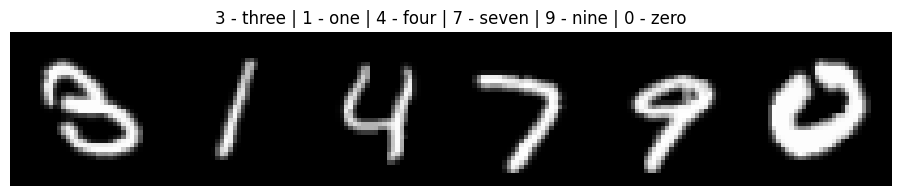

In [75]:
# Show some testing samples
show_samples(test_dataloader, class_names, binary=True)

## **Building The Model**

In [67]:
# Get number of output classes for prediction
num_classes = len(class_names)

# Specify the classifier's checkpoint based on dataset name
dataset_mapping = {"mnist":   "./Generative-Models/classifiers/mnist_best_classifier.pth",
                   "cifar10": "./Generative-Models/classifiers/cifar10_best_classifier.pth",
                   "flowers": "./Generative-Models/classifiers/flowers_best_classifier.pth"
                  }

# Load the classifier model to be used in the Inception score calculation
classifier_model = get_classifier_model(num_classes).to(device)
classifier_checkpoint = torch.load(dataset_mapping["mnist"], map_location=device)
classifier_model.load_state_dict(classifier_checkpoint)

<All keys matched successfully>

In [68]:
# Define the model's configuration   
model_config = {
                  'im_channels': 1,
                  'im_size': 32,
    
                  'down_channels': [32, 64, 128, 256],
                  'mid_channels': [256, 256, 128],
    
                  'down_sample': [True, True, False],
    
                  'time_emb_dim': 128,
    
                  'num_down_layers': 2,
                  'num_mid_layers': 2,
                  'num_up_layers': 2,
    
                  'num_heads': 4
    
                }

In [69]:
# Instantiate the model           
model = Unet(model_config).to(device)

In [70]:
# Specify training parameters
criterion = torch.nn.MSELoss()

In [71]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
#optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [72]:
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
#lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

## **Training The Model**

In [ ]:
train_model(model, optimizer, lr_scheduler, train_dataloader, epochs=700, early_stopping=False, checkpoint_path='./checkpoints/checkpoint.pt', device=device)

## **Evaluating The Model Performance**

In [74]:
metrics = eval_model(model, classifier_model, data_loader=test_dataloader, batch_size=32, im_channels=model_config['im_channels'], im_size=model_config['im_size'], num_samples=100, device=device)

Loading checkpoint: ./mnist.pt
Generated images shape: torch.Size([100, 1, 32, 32])
Real images shape: torch.Size([100, 1, 32, 32])
Real images reshaped to: torch.Size([100, 1, 32, 32])
Generated images reshaped to: torch.Size([100, 3, 32, 32])
FID score: 74.29588317871094
Inception Score: 5.109804630279541 +/- 0.7944774627685547


## **Generation**

In [ ]:
generate_samples(model_config, beta_start=0.0001, beta_end=0.02, num_timesteps=1000, num_samples=100)